In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    "../data/processed/gps_cleaned.csv"
)

df["timestamp"] = pd.to_datetime(
    df["timestamp"]
)

print("Shape:", df.shape)
df.head()

Shape: (24730077, 12)


,user_id,latitude,longitude,altitude,date,time,timestamp,hour,day,weekday,month,is_weekend
0,0,39.984702,116.318417,492.0,2008-10-23,02:53:04,2008-10-23 02:53:04,2,23,Thursday,10,False
1,0,39.984683,116.318450,492.0,2008-10-23,02:53:10,2008-10-23 02:53:10,2,23,Thursday,10,False
2,0,39.984686,116.318417,492.0,2008-10-23,02:53:15,2008-10-23 02:53:15,2,23,Thursday,10,False
3,0,39.984688,116.318385,492.0,2008-10-23,02:53:20,2008-10-23 02:53:20,2,23,Thursday,10,False
4,0,39.984655,116.318263,492.0,2008-10-23,02:53:25,2008-10-23 02:53:25,2,23,Thursday,10,False


In [3]:
df = df.sort_values(
    by=["user_id", "timestamp"]
).reset_index(drop=True)

df.head()

,user_id,latitude,longitude,altitude,date,time,timestamp,hour,day,weekday,month,is_weekend
0,0,39.984702,116.318417,492.0,2008-10-23,02:53:04,2008-10-23 02:53:04,2,23,Thursday,10,False
1,0,39.984683,116.318450,492.0,2008-10-23,02:53:10,2008-10-23 02:53:10,2,23,Thursday,10,False
2,0,39.984686,116.318417,492.0,2008-10-23,02:53:15,2008-10-23 02:53:15,2,23,Thursday,10,False
3,0,39.984688,116.318385,492.0,2008-10-23,02:53:20,2008-10-23 02:53:20,2,23,Thursday,10,False
4,0,39.984655,116.318263,492.0,2008-10-23,02:53:25,2008-10-23 02:53:25,2,23,Thursday,10,False


In [4]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate distance between two GPS coordinates in kilometers.
    """

    R = 6371.0

    lat1 = np.radians(lat1)
    lat2 = np.radians(lat2)

    delta_lat = np.radians(lat2 - lat1)
    delta_lon = np.radians(lon2 - lon1)

    a = (
        np.sin(delta_lat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(delta_lon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

In [5]:
df["previous_latitude"] = (
    df.groupby("user_id")["latitude"].shift(1)
)

df["previous_longitude"] = (
    df.groupby("user_id")["longitude"].shift(1)
)

df["previous_timestamp"] = (
    df.groupby("user_id")["timestamp"].shift(1)
)

In [6]:
df[
    [
        "user_id",
        "latitude",
        "longitude",
        "previous_latitude",
        "previous_longitude"
    ]
].head(10)

,user_id,latitude,longitude,previous_latitude,previous_longitude
0,0,39.984702,116.318417,NaN,NaN
1,0,39.984683,116.318450,39.984702,116.318417
2,0,39.984686,116.318417,39.984683,116.318450
3,0,39.984688,116.318385,39.984686,116.318417
4,0,39.984655,116.318263,39.984688,116.318385
5,0,39.984611,116.318026,39.984655,116.318263
6,0,39.984608,116.317761,39.984611,116.318026
7,0,39.984563,116.317517,39.984608,116.317761
8,0,39.984539,116.317294,39.984563,116.317517
9,0,39.984606,116.317065,39.984539,116.317294


In [7]:
df["distance_km"] = haversine_distance(
    df["previous_latitude"],
    df["previous_longitude"],
    df["latitude"],
    df["longitude"]
)

In [8]:
df["distance_km"] = df["distance_km"].fillna(0)

In [9]:
df["distance_km"].describe()

count    2.473008e+07
mean     4.998135e-02
std      1.082392e+01
min      0.000000e+00
25%      6.824609e-04
50%      2.922116e-03
75%      1.081858e-02
max      1.112816e+04
Name: distance_km, dtype: float64

In [10]:
df["time_difference_seconds"] = (
    df["timestamp"]
    - df["previous_timestamp"]
).dt.total_seconds()

df["time_difference_seconds"] = (
    df["time_difference_seconds"].fillna(0)
)

In [11]:
df["speed_kmh"] = np.where(
    df["time_difference_seconds"] > 0,
    df["distance_km"] /
    (df["time_difference_seconds"] / 3600),
    0
)

In [12]:
df["speed_kmh"].describe()

count    2.473008e+07
mean     4.432264e+01
std      5.922642e+03
min      0.000000e+00
25%      9.746284e-01
50%      4.174930e+00
75%      2.354677e+01
max      2.244170e+06
Name: speed_kmh, dtype: float64

In [13]:
df["speed_kmh"].sort_values(
    ascending=False
).head(20)

11796188    2.244170e+06
11796190    2.244063e+06
11796182    2.243888e+06
11796197    2.243885e+06
11796196    2.243818e+06
11796180    2.243745e+06
11796178    2.243582e+06
11796204    2.243550e+06
11796203    2.243480e+06
11796176    2.243400e+06
11796211    2.243253e+06
11796174    2.243215e+06
11796210    2.243178e+06
11796172    2.243012e+06
11796218    2.242969e+06
11796217    2.242896e+06
11796170    2.242812e+06
11796168    2.242605e+06
11796228    2.242542e+06
11796227    2.242465e+06
Name: speed_kmh, dtype: float64

In [14]:
df["speed_kmh"] = df["speed_kmh"].clip(
    upper=200
)

In [15]:
df["speed_kmh"].describe()

count    2.473008e+07
mean     1.683122e+01
std      2.597834e+01
min      0.000000e+00
25%      9.746284e-01
50%      4.174930e+00
75%      2.354677e+01
max      2.000000e+02
Name: speed_kmh, dtype: float64

In [16]:
user_total_distance = (
    df.groupby("user_id")["distance_km"]
    .sum()
    .reset_index()
)

user_total_distance.columns = [
    "user_id",
    "total_distance_km"
]

user_total_distance.head()

,user_id,total_distance_km
0,0,3698.487546
1,1,541.369687
2,2,3068.472610
3,3,8912.712756
4,4,6285.433318


In [17]:
user_average_speed = (
    df.groupby("user_id")["speed_kmh"]
    .mean()
    .reset_index()
)

user_average_speed.columns = [
    "user_id",
    "average_speed_kmh"
]

user_average_speed.head()

,user_id,average_speed_kmh
0,0,6.781412
1,1,7.610633
2,2,9.194402
3,3,8.774078
4,4,7.320590


In [18]:
user_max_speed = (
    df.groupby("user_id")["speed_kmh"]
    .max()
    .reset_index()
)

user_max_speed.columns = [
    "user_id",
    "maximum_speed_kmh"
]

user_max_speed.head()

,user_id,maximum_speed_kmh
0,0,200.0
1,1,200.0
2,2,200.0
3,3,200.0
4,4,200.0


In [19]:
df["location"] = (
    df["latitude"].round(4).astype(str)
    + "_"
    + df["longitude"].round(4).astype(str)
)

locations_visited = (
    df.groupby("user_id")["location"]
    .nunique()
    .reset_index()
)

locations_visited.columns = [
    "user_id",
    "number_of_locations"
]

locations_visited.head()

,user_id,number_of_locations
0,0,52014
1,1,30151
2,2,65933
3,3,131038
4,4,110382


In [20]:
visit_frequency = (
    df.groupby(
        ["user_id", "location"]
    )
    .size()
    .reset_index(name="visit_frequency")
)

visit_frequency.head()

,user_id,location,visit_frequency
0,0,31.0953_121.0547,1
1,0,31.0954_121.054,1
2,0,31.0957_121.0535,1
3,0,31.0957_121.0552,1
4,0,31.0962_121.0532,1


In [21]:
most_visited_location = (
    visit_frequency
    .sort_values(
        ["user_id", "visit_frequency"],
        ascending=[True, False]
    )
    .groupby("user_id")
    .first()
    .reset_index()
)

most_visited_location.head()

,user_id,location,visit_frequency
0,0,40.0097_116.3151,881
1,1,40.0138_116.3065,7154
2,2,39.9262_116.3375,1375
3,3,40.0076_116.3198,1863
4,4,39.9999_116.3274,1746


In [22]:
movement_by_hour = (
    df.groupby("hour")
    .size()
    .reset_index(name="movement_count")
)

movement_by_hour

,hour,movement_count
0,0,1385506
1,1,1508233
2,2,1341107
3,3,1261584
4,4,1259943
5,5,1250449
6,6,1335771
7,7,1401434
8,8,1465316
9,9,1713703


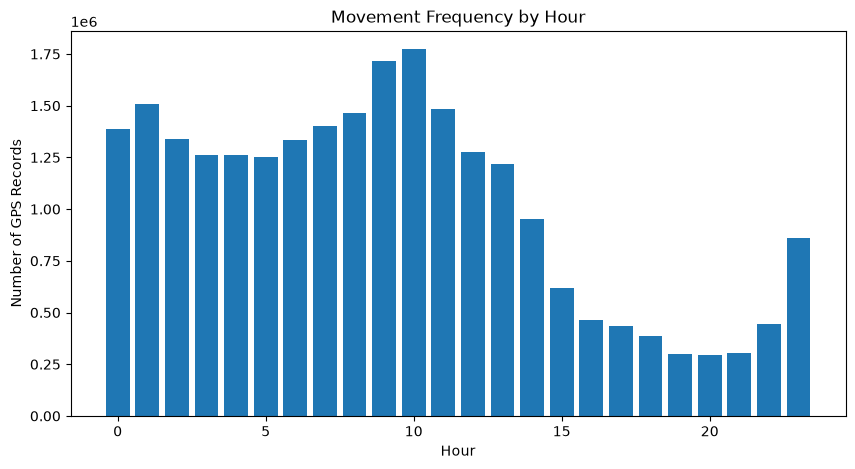

In [23]:
plt.figure(figsize=(10, 5))

plt.bar(
    movement_by_hour["hour"],
    movement_by_hour["movement_count"]
)

plt.xlabel("Hour")
plt.ylabel("Number of GPS Records")
plt.title("Movement Frequency by Hour")

plt.show()

In [24]:
movement_by_day = (
    df.groupby("weekday")
    .size()
    .reset_index(name="movement_count")
)

movement_by_day

,weekday,movement_count
0,Friday,3725418
1,Monday,3216523
2,Saturday,4364880
3,Sunday,3650091
4,Thursday,3454077
5,Tuesday,3028942
6,Wednesday,3290146


In [25]:
df["time_spent_minutes"] = (
    df["time_difference_seconds"] / 60
)

df["time_spent_minutes"] = (
    df["time_spent_minutes"]
    .clip(lower=0)
)

In [26]:
df["time_spent_minutes"].describe()

count    2.473008e+07
mean     1.992463e+00
std      1.095585e+03
min      0.000000e+00
25%      1.666667e-02
50%      3.333333e-02
75%      8.333333e-02
max      3.826746e+06
Name: time_spent_minutes, dtype: float64

In [27]:
user_features = user_total_distance.merge(
    user_average_speed,
    on="user_id",
    how="left"
)

user_features = user_features.merge(
    user_max_speed,
    on="user_id",
    how="left"
)

user_features = user_features.merge(
    locations_visited,
    on="user_id",
    how="left"
)

user_features.head()

,user_id,total_distance_km,average_speed_kmh,maximum_speed_kmh,number_of_locations
0,0,3698.487546,6.781412,200.0,52014
1,1,541.369687,7.610633,200.0,30151
2,2,3068.472610,9.194402,200.0,65933
3,3,8912.712756,8.774078,200.0,131038
4,4,6285.433318,7.320590,200.0,110382


In [28]:
average_time_spent = (
    df.groupby("user_id")["time_spent_minutes"]
    .mean()
    .reset_index()
)

average_time_spent.columns = [
    "user_id",
    "average_time_spent_minutes"
]

user_features = user_features.merge(
    average_time_spent,
    on="user_id",
    how="left"
)

user_features.head()

,user_id,total_distance_km,average_speed_kmh,maximum_speed_kmh,number_of_locations,average_time_spent_minutes
0,0,3698.487546,6.781412,200.0,52014,2.113603
1,1,541.369687,7.610633,200.0,30151,0.699754
2,2,3068.472610,9.194402,200.0,65933,0.869111
3,3,8912.712756,8.774078,200.0,131038,0.755496
4,4,6285.433318,7.320590,200.0,110382,0.912745


In [29]:
print("User-level feature dataset:")
print(user_features.shape)

print("\nColumns:")
print(user_features.columns.tolist())

print("\nMissing values:")
print(user_features.isnull().sum())

User-level feature dataset:
(182, 6)

Columns:
['user_id', 'total_distance_km', 'average_speed_kmh', 'maximum_speed_kmh', 'number_of_locations', 'average_time_spent_minutes']

Missing values:
user_id                       0
total_distance_km             0
average_speed_kmh             0
maximum_speed_kmh             0
number_of_locations           0
average_time_spent_minutes    0
dtype: int64


In [30]:
user_features.to_csv(
    "../data/processed/user_movement_features.csv",
    index=False
)

print("Feature dataset saved successfully!")

Feature dataset saved successfully!


In [31]:
enhanced_path = (
    "../data/processed/"
    "gps_movement_features.csv"
)

df.to_csv(
    enhanced_path,
    index=False
)

print("Enhanced GPS dataset saved:")
print(enhanced_path)

Enhanced GPS dataset saved:
../data/processed/gps_movement_features.csv


In [32]:
final_features = pd.read_csv(
    "../data/processed/"
    "gps_movement_features.csv"
)

print("Shape:", final_features.shape)

display(
    final_features[
        [
            "user_id",
            "latitude",
            "longitude",
            "timestamp",
            "distance_km",
            "speed_kmh",
            "time_spent_minutes"
        ]
    ].head(10)
)

Shape: (24730077, 20)


,user_id,latitude,longitude,timestamp,distance_km,speed_kmh,time_spent_minutes
0,0,39.984702,116.318417,2008-10-23 02:53:04,0.000000,0.000000,0.000000
1,0,39.984683,116.318450,2008-10-23 02:53:10,0.002812,1.687092,0.100000
2,0,39.984686,116.318417,2008-10-23 02:53:15,0.002812,2.024341,0.083333
3,0,39.984688,116.318385,2008-10-23 02:53:20,0.002726,1.962995,0.083333
4,0,39.984655,116.318263,2008-10-23 02:53:25,0.010395,7.484055,0.083333
5,0,39.984611,116.318026,2008-10-23 02:53:30,0.020192,14.538559,0.083333
6,0,39.984608,116.317761,2008-10-23 02:53:35,0.022578,16.256056,0.083333
7,0,39.984563,116.317517,2008-10-23 02:53:40,0.020789,14.967977,0.083333
8,0,39.984539,116.317294,2008-10-23 02:53:45,0.019000,13.679677,0.083333
9,0,39.984606,116.317065,2008-10-23 02:53:50,0.019511,14.048005,0.083333
